# FIX - Multilingual Politeness Notebook

FIX is built using the `exlib` library, which we load using a local version for now. You can uncomment the `!pip install exlib` line and comment out the `import sys; sys.path.insert(0, "../../src")` line if you do not have a local version you are testing.

In [ ]:
import sys; sys.path.insert(0, '../../src')
import numpy as np
import pandas as pd
import torch
!pip install exlib captum
import exlib

In [ ]:
import torch
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification, AutoTokenizer
import numpy as np
import pandas as pd
import tqdm
from tqdm import tqdm
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import load_dataset
import sentence_transformers

from exlib.datasets.multilingual_politeness import PolitenessDataset, PolitenessClassifier, PolitenessFixScore, get_politeness_scores
from exlib.datasets.politeness_helper import load_lexica

from exlib.features.text import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ModuleNotFoundError: No module named 'exlib'

## Load datasets and pre-trained model

### Sample inference on dataset

In [ ]:
dataset = EmotionDataset("test")
dataloader = DataLoader(dataset, batch_size=2, shuffle=False)
model = EmotionClassifier().eval().to(device)

In [ ]:
torch.manual_seed(1234)

dataset = PolitenessDataset("test")
dataloader = DataLoader(dataset, batch_size=4, shuffle=False)
model = PolitenessClassifier()
model.to(device)
model.eval();

In [ ]:
for batch in tqdm(dataloader):
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    output = model(input_ids, attention_mask)
    utterances = [dataset.tokenizer.decode(input_id, skip_special_tokens=True) for input_id in input_ids]
    for utterance, label in zip(utterances, output):
        print("Text: {}\nPoliteness: {}\n".format(utterance, label.item()))
    break


  0%|          | 0/143 [00:00<?, ?it/s]

Text: The intro mentions the ISO 8601 international standard adopted in most western countries. What does this even mean? Who are we suggesting has done the adoption?
Politeness: 0.21642017364501953

Text: I'm a user on PrettyCure.org, and somebody on the site said they are making a fourth season of PreCure. It's a rumuor, but is it true? That person said it's more like Tokyo Mew Mew, a group of girls.
Politeness: 0.21494856476783752

Text: Hello fellow Wikipedians, I have just added archive links to on Essen. Please take a moment to review my edit. If necessary, add after the link to keep me from modifying it.
Politeness: 0.12163663655519485

Text: I saw the template citing this issue and since there was no section here discussing it I've decided to start one. I'm a Canadian and most of our television programs are also aired in the US so my knowledge of what's on TV outside of North America is limited. So I'm not sure of how much help I can be, but I do have some ideas on how to impro

## Baselines

In [ ]:
all_baselines_scores = get_politeness_scores(baselines = ['word', 'phrase', 'sentence'])

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at BrachioLab/xlm-roberta-politeness and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

100%|██████████| 143/143 [02:03<00:00,  1.15it/s]


---- phrase Level Groups ----


100%|██████████| 143/143 [02:49<00:00,  1.19s/it]


---- sentence Level Groups ----


100%|██████████| 143/143 [02:48<00:00,  1.18s/it]


In [ ]:
for name in all_baselines_scores:
    metric = torch.tensor(all_baselines_scores[name])
    mean_metric = metric.nanmean()
    print(f'BASELINE {name} mean score: {mean_metric}')

BASELINE word mean score: 0.683918263743679
BASELINE phrase mean score: 0.6350535131821455
BASELINE sentence mean score: 0.6108726893835531


### BERTopic (Clustering)

create topics from the dataset

In [ ]:
# first, save all the utterances

dataset = PolitenessDataset("test")
utterances = [' '.join(dataset[i]['word_list']) for i in range(len(dataset))]
# torch.save(utterances, '../../fix/utterances/multilingual_politeness_test.pt')

In [ ]:
# then, install bertopic + use them on the utterances

!pip install bertopic

In [ ]:
all_baselines_scores = get_politeness_scores(baselines = ['clustering'])
# make sure utterances_path is set to where utteraces is saved in your directory

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at BrachioLab/xlm-roberta-politeness and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


---- clustering Level Groups ----


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

100%|██████████| 143/143 [00:25<00:00,  5.62it/s]


In [ ]:
for name, score in all_baselines_scores.items():
    print(f'BASELINE {name} mean score: {score.mean()}')

BASELINE clustering mean score: 0.6679689437673803


In [ ]:
lexica = pd.read_csv(
    "https://huggingface.co/datasets/BrachioLab/multilingual_politeness_helper/resolve/main/english_politelex.csv"
)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
model = AutoModelForSequenceClassification.from_pretrained(
    "BrachioLab/xlm-roberta-politeness"
).to(device)
model.eval()


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at BrachioLab/xlm-roberta-politeness and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=

In [ ]:
def predict_proba(texts):
    inputs = tokenizer(texts, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)
    return probs[:, 1].detach().cpu().numpy()  # politeness probability


Grad-CAM mask shape: torch.Size([1, 1, 360, 640])
Expert mask shape: torch.Size([1, 4, 360, 640])


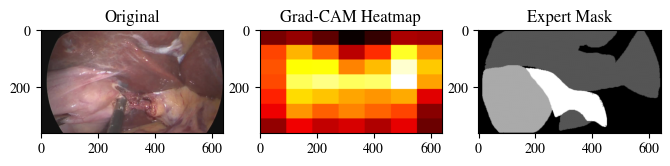

FIX Score: 0.010523405857384205


In [ ]:
import torch
import torch.nn.functional as F
import torchvision
from torchvision import models, transforms
import matplotlib.pyplot as plt
import numpy as np
from captum.attr import LayerGradCam, LayerAttribution
from exlib.datasets.cholec import CholecDataset, CholecFixScore

all_baseline_scores = {}
dataset = CholecDataset(split="test")
item = dataset[0]
image = item["image"].unsqueeze(0)
organs = item["organs"]

model = models.resnet18(pretrained=True).eval()

original_h, original_w = image.shape[-2:]


transform = transforms.Compose([
    transforms.Resize((224,224)),
])
image_resized = transform(image)

target_layer = model.layer4[-1]


gradcam = LayerGradCam(model, target_layer)
output = model(image_resized)
target_class = output.argmax(dim=1).item()
attribution = gradcam.attribute(image_resized, target=target_class)


upsampled_attr = LayerAttribution.interpolate(attribution, (original_h, original_w))


cam_map = upsampled_attr.squeeze().detach().numpy()
cam_map = (cam_map - cam_map.min()) / (cam_map.max() - cam_map.min())


threshold = np.percentile(cam_map, 90)
gradcam_mask = torch.tensor((cam_map > threshold).astype(np.int64)).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)


organs_mask = F.one_hot(organs.squeeze(0)).permute(2,0,1).unsqueeze(0).float()  # (1,C,H,W)

print(f"Grad-CAM mask shape: {gradcam_mask.shape}")
print(f"Expert mask shape: {organs_mask.shape}")


plt.figure(figsize=(8,3))
plt.subplot(1,3,1); plt.imshow(image[0].permute(1,2,0)); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(cam_map, cmap="hot"); plt.title("Grad-CAM Heatmap")
plt.subplot(1,3,3)
plt.imshow(organs.squeeze().numpy(), cmap="gray")
plt.title("Expert Mask")
plt.show()


metric = CholecFixScore()

fix_score = metric(groups_pred=gradcam_mask, groups_true=organs_mask)
all_baseline_scores["gradcam"] = fix_score.mean().item()
print("FIX Score:", fix_score.mean().item())

In [ ]:
from captum.attr import GuidedBackprop

In [ ]:
from torchvision.models import resnet18
model = resnet18(pretrained=True).to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
def guided_backprop_groups(image, model):
    """
    image: (1,C,H,W) tensor
    model: torch.nn.Module
    returns: (H,W) guided backprop map
    """
    gbp = GuidedBackprop(model)

    # Forward pass to pick target index
    output = model(image)
    target = output.argmax(dim=1)  # pick the max logit for each sample

    # Compute Guided Backprop
    attr = gbp.attribute(image, target=target)

    # Reduce channels
    gb_map = attr.abs().mean(dim=1).squeeze(0)  # (H,W)
    return gb_map


In [ ]:
all_fix_scores = []

for item in dataset:
    image = item["image"].unsqueeze(0).to(device)
    expert_mask = item["organs"].to(device)

    gb_map = guided_backprop_groups(image, model).unsqueeze(0)
    gb_map = gb_map.unsqueeze(0)

    num_classes = expert_mask.max().item() + 1
    expert_mask = expert_mask.squeeze(0)  # now (H,W)

    num_classes = expert_mask.max().item() + 1
    organ_mask = F.one_hot(expert_mask, num_classes=num_classes)
    organ_mask = organ_mask.permute(2,0,1).unsqueeze(0).float()

    fix_score = metric(groups_pred=gb_map, groups_true=organ_mask)
    all_fix_scores.append(fix_score.item())

all_fix_scores = torch.tensor(all_fix_scores)
print("Guided Backprop FIX score:", all_fix_scores.mean().item())

Guided Backprop FIX score: 0.4809398055076599


In [ ]:
import argparse
import os
import sys
from pathlib import Path
import torch

sys.path.append("../src")
import exlib
from exlib.datasets.cholec import get_cholec_scores
from exlib.datasets.chestx import get_chestx_scores
from exlib.datasets.mass_maps import get_mass_maps_scores
from exlib.datasets.supernova import get_supernova_scores
from exlib.datasets.multilingual_politeness import get_politeness_scores
from exlib.datasets.emotion import get_emotion_scores

In [ ]:
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from exlib.datasets.cholec import *
from exlib.features.vision import *

In [ ]:
import torch
from pathlib import Path

# Import the scoring functions
from exlib.datasets.cholec import get_cholec_scores

all_baseline_scores = get_cholec_scores(num_todo=None, batch_size=8)

ModuleNotFoundError: No module named 'exlib'